In [3]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import os
from astropy.constants import c
from astropy import constants as const
import astropy.units as u
from scipy import special


def weight(n):
    return 2 * n**2

def boltzmann(n1, n2, eV, T):
    k = 8.6173303e-5  # Boltzmann constant in eV/K
    g_n = weight(n2) / weight(n1) * np.exp(-eV / (k * T))
    return g_n

def CIV(T):
    sigma_Lya = 5.9e-14 * (T / 1e4) ** (-1/2)
    sigma_CIV = (0.19 / 0.4164) * sigma_Lya * (12) ** (0.5)
    N_CIV_0 = 1 / sigma_CIV
    return sigma_Lya, sigma_CIV, N_CIV_0

sig_ly, sig_c, N_CIV_0 = CIV(1e5)
print("{:.2e}".format(N_CIV_0))

def tau(sig_c, x):
    return sig_c * x

rr = np.arange(12, 17, 1)
ee = [0,1,2,3,4,5,6,7,8,9,10]


rr_reshaped = rr.reshape(-1, 1)
total_N_c = 10**rr_reshaped * ee / 10
total_N_c = total_N_c.flatten()

C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm
cc = c.to(u.cm / u.s).value
v_th = 11.7673179819719e5  # cm/s

K_gamma = 2.65e+8
H_gamma = 2.64e+8
f_CIV_K = 0.190
f_CIV_H = 0.0952

directory_1 = '~/RT/C_IV/code_tes/data_photon_1e6/'
path_sp_1 = f'{directory_1}N_atom000E+00_Vexp000E+00_Vemit500E+01_tauD000E+00_Vran118E+01spec_com.dat'

data_sp_1 = pd.read_csv(path_sp_1, sep='\s+', header=None)
sp_dlam_1 = data_sp_1[0]
yy_g= data_sp_1[1]
# # plt.plot(data_sp_1[0],data_sp_1[1])

nu_space = (cc / (sp_dlam_1 * 1e-8))
del_V_space_g = (sp_dlam_1 *1e-8/ C_IV_K - 1) * cc / 1e5  # km/s

Del_V_H = (C_IV_H/ C_IV_K - 1)* cc / 1e5 

print(Del_V_H)


def gauss_func(F_c,x,x_0,sig):
    xx = np.linspace(x.min(),x.max(),1000)
    ss = (xx-x_0)/sig
    ex = np.zeros(len(xx))
    ex = F_c*np.exp(-ss**2/2)
    return  xx,ex

# plt.plot(del_V_space_g,yy_g)

3.39e+13
500.56195015849033


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.constants import c
import astropy.units as u

# 데이터 및 상수 설정
rr = np.arange(12, 17, 1)
ee = [-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,9,10]
# ee=[2]

rr_reshaped = rr.reshape(-1, 1)
total_N_c = 10**rr_reshaped * ee / 10
total_N_c = total_N_c.flatten()

C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm
cc = c.to(u.cm / u.s).value
v_th = 11.7673179819719e5  # cm/s

K_gamma = 2.65e+8
H_gamma = 2.64e+8
f_CIV_K = 0.190
f_CIV_H = 0.0952

nu_C_IV_K = cc / C_IV_K  # s-1
nu_C_IV_H = cc / C_IV_H  # s-1

xx_1 = np.zeros(len(rr) * len(ee))
scat_1 = np.zeros(len(rr) * len(ee))

directory_1 = '~/RT/C_IV/code_tes/data_C_IV_out/'
n = 0

for ii, num in enumerate(rr):
    for jj, bb in enumerate(ee):
        if bb == 0:
            path_sp_1 = f'{directory_1}N_atom320E+{num}_Vexp{bb}00E+00_Vemit500E+01_tauD000E+00_Vran118E+01spec_com.dat'
        elif bb == 10 :
            gg = 1
            path_sp_1 = f'{directory_1}N_atom320E+{num}_Vexp{gg}00E+03_Vemit500E+01_tauD000E+00_Vran118E+01spec_com.dat'
        elif  bb == -10:
            gg = -1
            path_sp_1 = f'{directory_1}N_atom320E+{num}_Vexp{gg}00E+03_Vemit500E+01_tauD000E+00_Vran118E+01spec_com.dat'
        else:
            path_sp_1 = f'{directory_1}N_atom320E+{num}_Vexp{bb}00E+02_Vemit500E+01_tauD000E+00_Vran118E+01spec_com.dat'


        # 데이터 읽기
        try:
            data_sp_1 = pd.read_csv(path_sp_1, sep='\s+', header=None)
        except FileNotFoundError:
            print(f"파일을 찾을 수 없습니다: {path_sp_1}")
            continue

        sp_dlam_1 = data_sp_1[0].to_numpy()
        sp_1 = data_sp_1[1].to_numpy()

        indices_K_1 = np.where(sp_dlam_1 <= 1550)[0]
        indices_H_1 = np.where(sp_dlam_1 > 1550)[0]

        sp_dlam_K = sp_dlam_1[indices_K_1]
        sp_dlam_H = sp_dlam_1[indices_H_1]

        dlam_k = sp_dlam_K[1]-sp_dlam_K[0]
        dlam_h = sp_dlam_H[1]-sp_dlam_H[0]
        dlam_sp =sp_dlam_1[1] -sp_dlam_1[0]
        # print(dlam_k ,dlam_h,dlam_sp)

        sp_K = sp_1[indices_K_1]
        sp_H = sp_1[indices_H_1]

        if len(sp_K) == 0 or len(sp_H) == 0:
            print(f"데이터 부족: {path_sp_1}")
            continue

        nu_space = (cc / (sp_dlam_1 * 1e-8))
        del_V_space = (nu_C_IV_K / nu_space - 1) * cc / 1e5  # km/s


        indices_K_V = np.where((del_V_space<100)& (del_V_space>-100))[0]
        indices_H_V = np.where((del_V_space<600)& (del_V_space>400))[0]

        sp_V_K = del_V_space[indices_K_V]
        sp_V_H = del_V_space[indices_H_V]

        sp_K_f = sp_1[indices_K_V]
        sp_H_f = sp_1[indices_H_V] 

        KK = np.argmax(sp_K_f)
        HH = np.argmax(sp_H_f)
        K_line_peak_flux = sp_K_f[KK]
        H_line_peak_flux = sp_H_f[HH]



        pp_1 = np.where(sp_1 == K_line_peak_flux)[0]
        pp_1 = pp_1[0] if pp_1.size > 0 else None
        pp_2 = np.where(sp_1 == H_line_peak_flux)[0]
        pp_2 = pp_2[-1] if pp_2.size > 0 else None

        peak_K_V, peak_K_flux = del_V_space[pp_1], sp_1[pp_1]
        peak_H_V, peak_H_flux = del_V_space[pp_2], sp_1[pp_2]


        delta_lam = (sp_dlam_1 - 1548.187 )





        del_V_space_K = (peak_K_V/ sp_V_K - 1) * cc / 1e5  # km/s
        del_V_space_H = (peak_H_V/ nu_space - 1) * cc / 1e5  # km/s


        globals()[f'K_dv_{bb}_{num}'] = del_V_space_K

        globals()[f'Kf_{bb}_{num}'] =sp_K_f

        # print(len(del_V_space_K),len(sp_K_f))


        globals()[f'H_dv_{bb}_{num}'] = del_V_space_H
        globals()[f'Hf_{bb}_{num}'] = sp_H_f

        sep_point = abs(peak_H_V - peak_K_V) / 2
        # print(sep_point)
        indices_K_sp = np.where(del_V_space <= sep_point)[0]
        indices_H_sp = np.where(del_V_space > sep_point)[0]

        int_Vel_K = del_V_space[indices_K_sp]
        int_Vel_H = del_V_space[indices_H_sp]

        int_flux_K = sp_1[indices_K_sp]
        int_flux_H = sp_1[indices_H_sp]

        delta_lam_K = delta_lam[indices_K_sp]
        delta_lam_H = delta_lam[indices_H_sp]
        globals()[f'delta_lam_K_{bb}_{num}'] = delta_lam_K
        globals()[f'delta_lam_H_{bb}_{num}'] = delta_lam_H  

        H_nu = (C_IV_H/C_IV_K -1 )*cc/1e5

        dh = peak_H_V - H_nu  
        globals()[f'I_K_dv_{bb}_{num}'] = int_Vel_K 
        globals()[f'I_K_f_{bb}_{num}'] = int_flux_K

        globals()[f'I_H_dv_{bb}_{num}'] = int_Vel_H  
        globals()[f'I_H_f_{bb}_{num}'] = int_flux_H      

Text(640, 1.07, '$\\rm V_{\\rm exp} = 500\\,\\rm km\\,s^{-1}$')

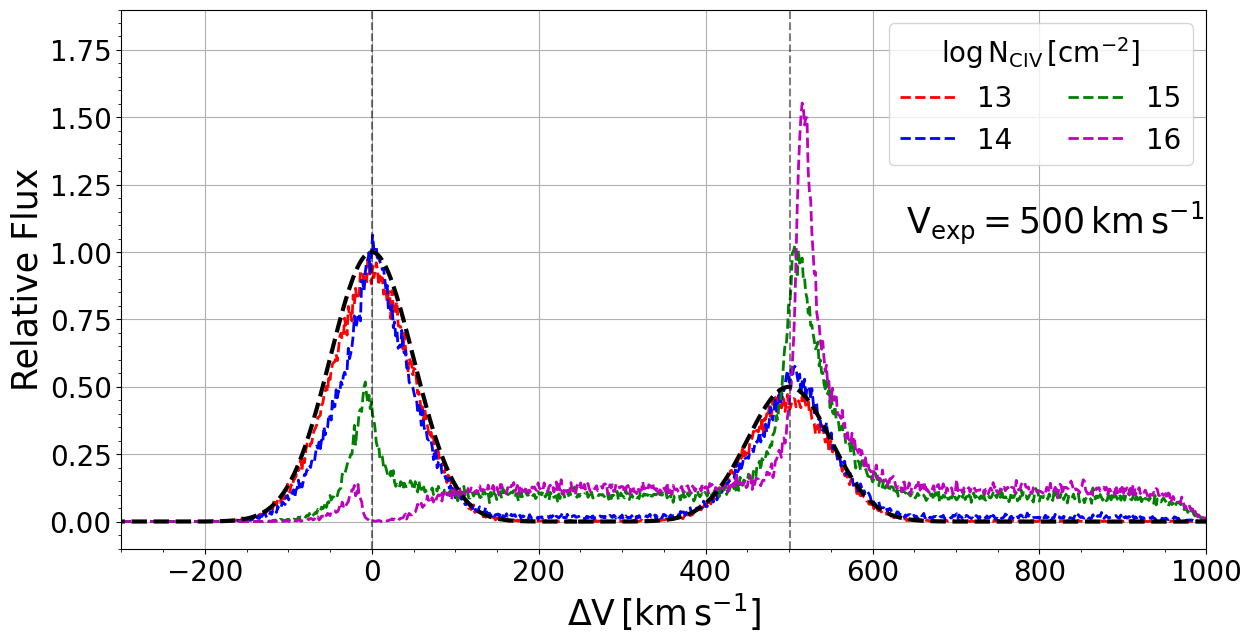

In [5]:
fig = plt.figure(1,figsize=(14,7))



focus_exp = 5
v_emit = 50
dnu = (nu_C_IV_K/nu_C_IV_H -1)*cc/1e5

normal_f = yy_g.max() 



n_1 = 13
plt.plot(globals()[f'I_K_dv_{focus_exp}_{n_1}'],globals()[f'I_K_f_{focus_exp}_{n_1}'] / normal_f ,'r--',lw=2,label=f'{n_1}')
plt.plot(globals()[f'I_H_dv_{focus_exp}_{n_1}'],globals()[f'I_H_f_{focus_exp}_{n_1}'] / normal_f ,'r--',lw=2)

xx_k,int_gau_K= gauss_func(normal_f,globals()[f'I_K_dv_{focus_exp}_{n_1}'],0,50)
xx_h,int_gau_H= gauss_func(normal_f,globals()[f'I_H_dv_{focus_exp}_{n_1}'],500,50)

# nn = globals()[f'I_K_f_{focus_exp}_13']
n_2 = 14
plt.plot(globals()[f'I_K_dv_{focus_exp}_{n_2}'],globals()[f'I_K_f_{focus_exp}_{n_2}']/normal_f ,'b--',lw=2,label=f'{n_2}')
plt.plot(globals()[f'I_H_dv_{focus_exp}_{n_2}'],globals()[f'I_H_f_{focus_exp}_{n_2}']/normal_f ,'b--',lw=2)

n_3 = 15
plt.plot(globals()[f'I_K_dv_{focus_exp}_{n_3}'],globals()[f'I_K_f_{focus_exp}_{n_3}'] / normal_f ,'g--',lw=2,label=f'{n_3}')
plt.plot(globals()[f'I_H_dv_{focus_exp}_{n_3}'],globals()[f'I_H_f_{focus_exp}_{n_3}']/normal_f  ,'g--',lw=2)

n_4 = 16
plt.plot(globals()[f'I_K_dv_{focus_exp}_{n_4}'],globals()[f'I_K_f_{focus_exp}_{n_4}'] / normal_f ,'m--',lw=2,label=f'{n_4}')
plt.plot(globals()[f'I_H_dv_{focus_exp}_{n_4}'],globals()[f'I_H_f_{focus_exp}_{n_4}'] / normal_f ,'m--',lw=2)


# plt.plot(del_V_space_g,yy_g / normal_f,'k--',lw=2,alpha=1)

plt.plot(xx_k,int_gau_K/normal_f,'k--',lw=3)
plt.plot(xx_h,int_gau_H/normal_f/2,'k--',lw=3)

plt.xlim(-300, 1000)
plt.minorticks_on()
plt.grid(True)
plt.legend(loc='upper right',fontsize=20,ncol=2,title=r'$\log{{\rm N}_{\rm C IV}}\,[\rm cm ^{-2}]$',title_fontsize=20)
plt.xlabel(r'$\Delta \rm V \, [\rm km\,s^{-1}]$',fontsize=25)
plt.ylabel(r'Relative Flux',fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.axvline(x=0,ymin=0,ymax=5,color='k',linestyle='--',alpha=0.5)
plt.axvline(x=dnu,ymin=0,ymax=5,color='k',linestyle='--',alpha=0.5)
plt.ylim(-0.1,1.9)
plt.text(640, 1.07, f'$\\rm V_{{\\rm exp}} = {focus_exp}00\\,\\rm km\\,s^{{-1}}$', size=25, fontweight='bold')
#400 -> 2.1
#500 -> 0.97

# plt.savefig(f'/home/jin/바탕화면/DelV_gauss_source_density_{focus_exp}00km.pdf',bbox_inches='tight')

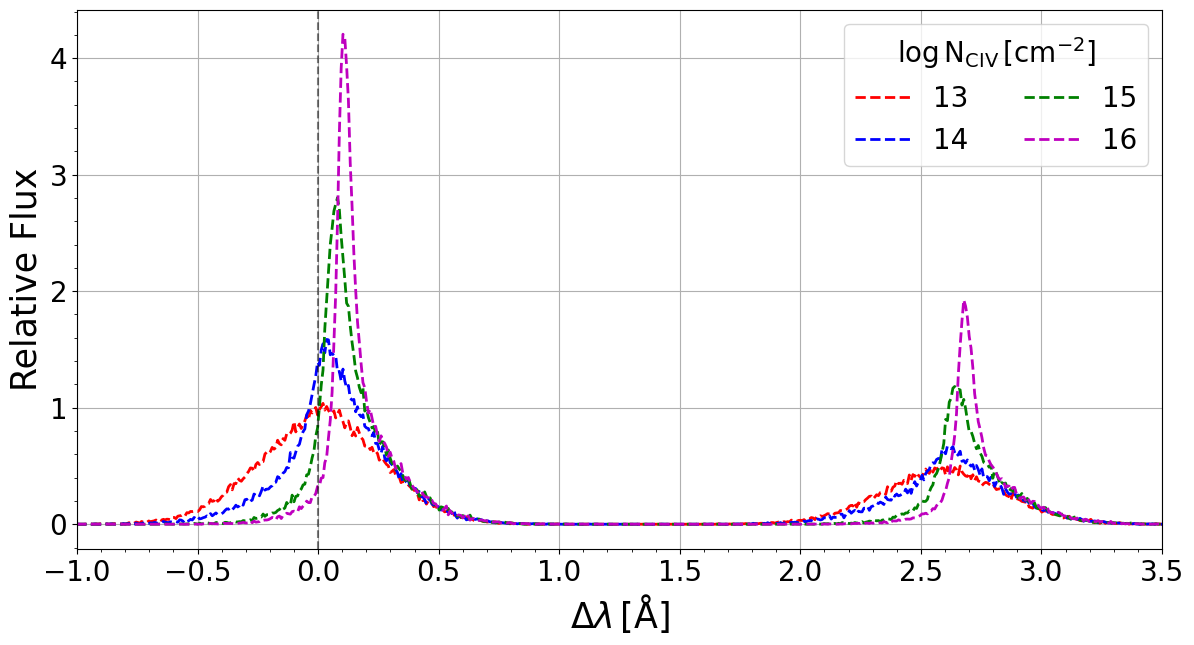

In [28]:
fig = plt.figure(1,figsize=(14,7))



focus_exp = 2
v_emit = 50
dnu = (nu_C_IV_K/nu_C_IV_H -1)*cc/1e5

normal_f = yy_g.max() 


n_1 = 13
plt.plot(globals()[f'delta_lam_K_{focus_exp}_{n_1}'],globals()[f'I_K_f_{focus_exp}_{n_1}'] / normal_f ,'r--',lw=2,label=f'{n_1}')
plt.plot(globals()[f'delta_lam_H_{focus_exp}_{n_1}'],globals()[f'I_H_f_{focus_exp}_{n_1}'] / normal_f ,'r--',lw=2)

xx_k,int_gau_K= gauss_func(normal_f,globals()[f'delta_lam_K_{focus_exp}_{n_1}'],0,50)
xx_h,int_gau_H= gauss_func(normal_f,globals()[f'delta_lam_H_{focus_exp}_{n_1}'],500,50)

# nn = globals()[f'I_K_f_{focus_exp}_13']
n_2 = 14
plt.plot(globals()[f'delta_lam_K_{focus_exp}_{n_2}'],globals()[f'I_K_f_{focus_exp}_{n_2}']/normal_f ,'b--',lw=2,label=f'{n_2}')
plt.plot(globals()[f'delta_lam_H_{focus_exp}_{n_2}'],globals()[f'I_H_f_{focus_exp}_{n_2}']/normal_f ,'b--',lw=2)

n_3 = 15
plt.plot(globals()[f'delta_lam_K_{focus_exp}_{n_3}'],globals()[f'I_K_f_{focus_exp}_{n_3}'] / normal_f ,'g--',lw=2,label=f'{n_3}')
plt.plot(globals()[f'delta_lam_H_{focus_exp}_{n_3}'],globals()[f'I_H_f_{focus_exp}_{n_3}']/normal_f  ,'g--',lw=2)

n_4 = 16
plt.plot(globals()[f'delta_lam_K_{focus_exp}_{n_4}'],globals()[f'I_K_f_{focus_exp}_{n_4}'] / normal_f ,'m--',lw=2,label=f'{n_4}')
plt.plot(globals()[f'delta_lam_H_{focus_exp}_{n_4}'],globals()[f'I_H_f_{focus_exp}_{n_4}'] / normal_f ,'m--',lw=2)


# plt.plot(del_V_space_g,yy_g / normal_f,'k--',lw=2,alpha=1)

# plt.plot(xx_k,int_gau_K/normal_f,'k--',lw=3)
# plt.plot(xx_h,int_gau_H/normal_f/2,'k--',lw=3)

plt.xlim(-1.0, 3.5)

plt.minorticks_on()
plt.grid(True)
plt.legend(loc='upper right',fontsize=20,ncol=2,title=r'$\log{{\rm N}_{\rm C IV}}\,[\rm cm ^{-2}]$',title_fontsize=20)
plt.xlabel(r'$\Delta \lambda \, [\rm \AA]$',fontsize=25)
plt.ylabel(r'Relative Flux',fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.axvline(x=0,ymin=0,ymax=5,color='k',linestyle='--',alpha=0.5)
plt.axvline(x=dnu,ymin=0,ymax=5,color='k',linestyle='--',alpha=0.5)
# plt.ylim(-0.1,1.9)
# plt.text(640, 1.07, f'$\\rm V_{{\\rm exp}} = {focus_exp}00\\,\\rm km\\,s^{{-1}}$', size=25, fontweight='bold')
#400 -> 2.1

In [49]:
k = cc/1e5

lamm = 1548*(1+ 2*500/ k)
lamm 


np.float64(1553.1635721936675)

(array([-0.5,  0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5]),
 [Text(0, -0.5, '−0.5'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.5, '0.5'),
  Text(0, 1.0, '1.0'),
  Text(0, 1.5, '1.5'),
  Text(0, 2.0, '2.0'),
  Text(0, 2.5, '2.5'),
  Text(0, 3.0, '3.0'),
  Text(0, 3.5, '3.5')])

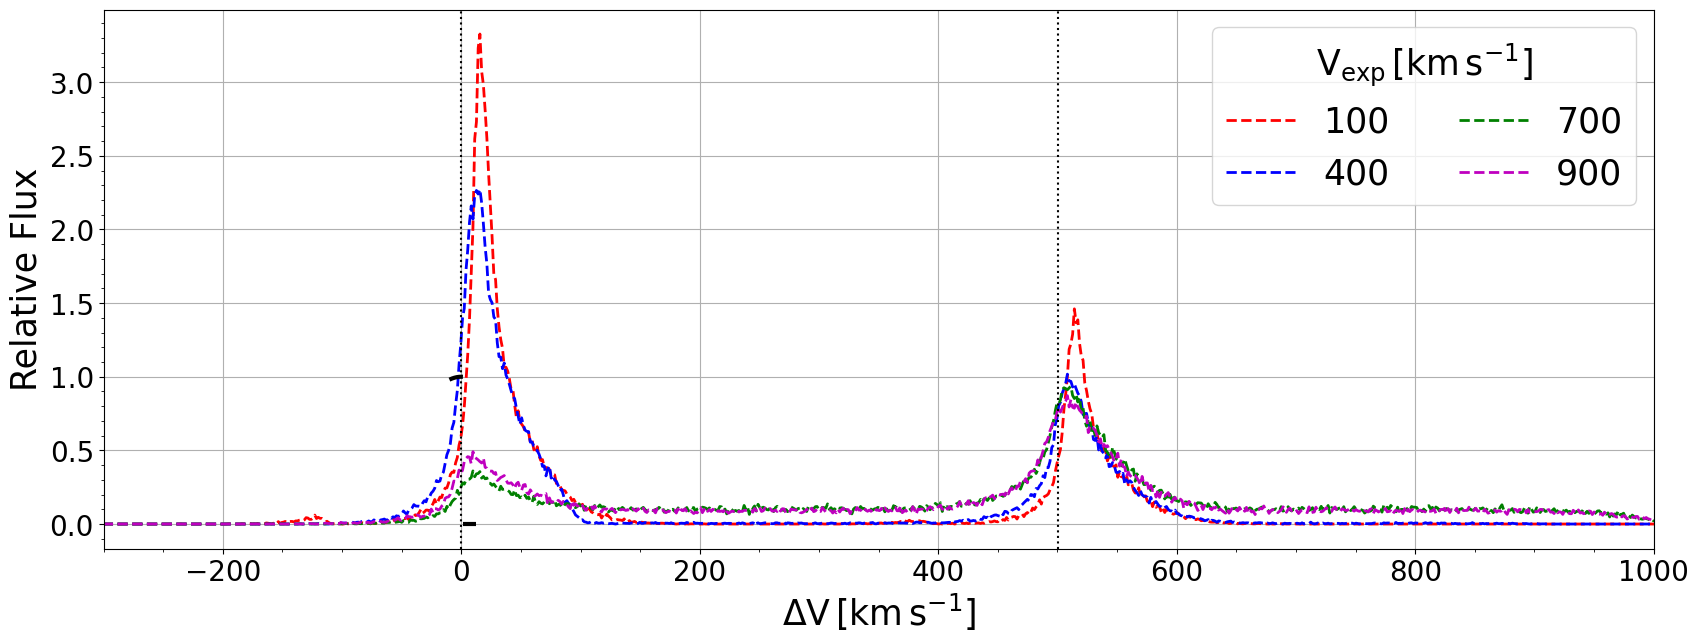

In [55]:
fig = plt.figure(1,figsize=(20,7))

focus_col = 15


normal_f = yy_g.max() 

n_1 = 1
plt.plot(globals()[f'I_K_dv_{n_1}_{focus_col}'],globals()[f'I_K_f_{n_1}_{focus_col}']/normal_f,'r--',lw=2,label=f'{n_1}00')
plt.plot(globals()[f'I_H_dv_{n_1}_{focus_col}'],globals()[f'I_H_f_{n_1}_{focus_col}']/normal_f,'r--',lw=2)

n_2 = 4
plt.plot(globals()[f'I_K_dv_{n_2}_{focus_col}'],globals()[f'I_K_f_{n_2}_{focus_col}']/normal_f,'b--',lw=2,label=f'{n_2}00')
plt.plot(globals()[f'I_H_dv_{n_2}_{focus_col}'],globals()[f'I_H_f_{n_2}_{focus_col}']/normal_f,'b--',lw=2)

n_3 = 7
plt.plot(globals()[f'I_K_dv_{n_3}_{focus_col}'],globals()[f'I_K_f_{n_3}_{focus_col}']/normal_f,'g--',lw=2,label=f'{n_3}00')
plt.plot(globals()[f'I_H_dv_{n_3}_{focus_col}'],globals()[f'I_H_f_{n_3}_{focus_col}']/normal_f,'g--',lw=2)

n_4 = 9
plt.plot(globals()[f'I_K_dv_{n_4}_{focus_col}'],globals()[f'I_K_f_{n_4}_{focus_col}']/normal_f,'m--',lw=2,label=f'{n_4}00')
plt.plot(globals()[f'I_H_dv_{n_4}_{focus_col}'],globals()[f'I_H_f_{n_4}_{focus_col}']/normal_f,'m--',lw=2)



# plt.plot(del_V_space_g,yy_g / normal_f,'k--',lw=2,alpha=1)
plt.plot(xx_k,int_gau_K/normal_f,'k--',lw=3)
plt.plot(xx_h,int_gau_H/normal_f/2,'k--',lw=3)


plt.axvline(x=0,ymin=0,ymax=5,color='k',linestyle=':')
dnu = (nu_C_IV_K/nu_C_IV_H -1)*cc/1e5
plt.axvline(x=dnu,ymin=0,ymax=5,color='k',linestyle=':')


plt.xlim(-300, 1000)
plt.minorticks_on()
plt.grid(True)
plt.legend(loc='upper right',fontsize=25,ncol=2,title=r'$\rm V_{\rm exp} \, [\rm km \, s^{-1}]$',title_fontsize=25)
plt.xlabel(r'$\Delta \rm V \, [\rm km\,s^{-1}]$',fontsize=25)
plt.ylabel(r'Relative Flux',fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)




# plt.savefig('/home/jin/바탕화면/DelV_15_gauss_source_Vexp.pdf',bbox_inches='tight')


([<matplotlib.axis.YTick at 0x7a0c7f53a380>,
 [Text(0, 0.1, '$\\mathdefault{10^{-1}}$'),
  Text(0, 1.0, '$\\mathdefault{10^{0}}$'),
  Text(0, 10.0, '$\\mathdefault{10^{1}}$')])

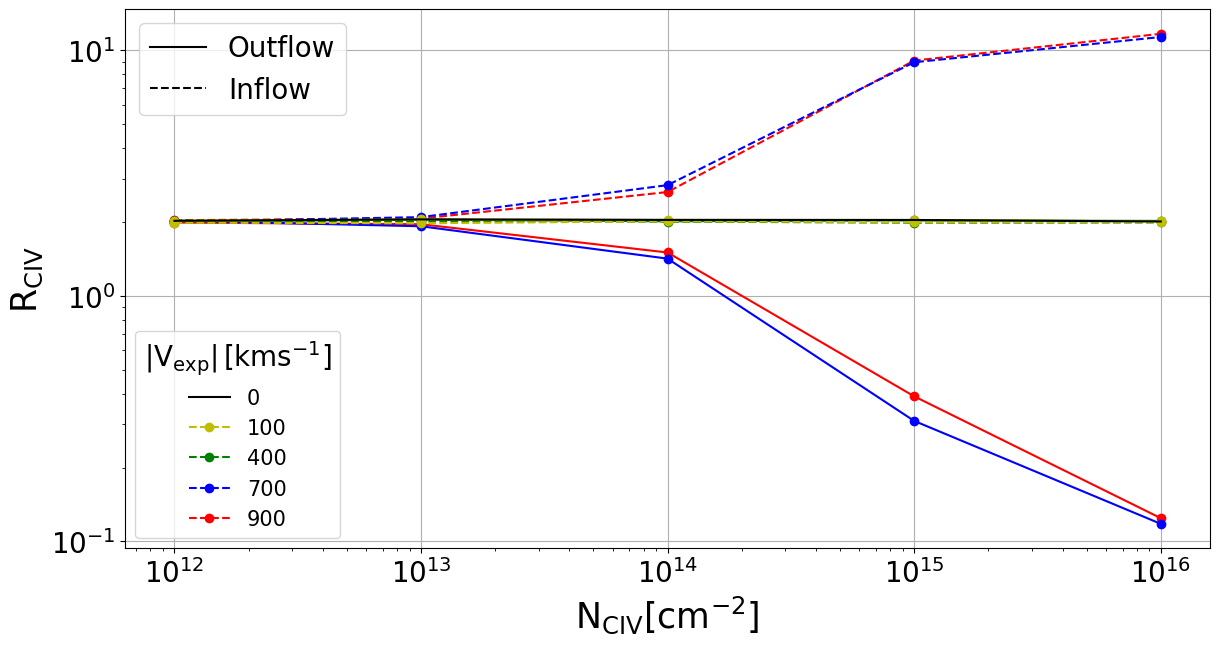

In [63]:
def inf(x,y):
    summ = np.zeros(len(y))
    dx = x[1]- x[0]
    summ = np.sum(dx*y,axis=0)
    return summ

ratio = np.zeros((len(ee),len(rr)))

for ii,jj in enumerate(ee):
    for aa,bb in enumerate(rr):
        a_1 = inf(globals()[f'I_K_dv_{jj}_{bb}'],globals()[f'I_K_f_{jj}_{bb}'])
        a_2 = inf(globals()[f'I_H_dv_{jj}_{bb}'],globals()[f'I_H_f_{jj}_{bb}'])
        ratio[ii][aa] = a_1/a_2

fig = plt.figure(1,figsize=(14,7))
from matplotlib.ticker import ScalarFormatter
# for ii, jj in enumerate(ee):



# plt.plot(10**(rr), ratio[0][:], 'ro--',alpha=1,label='1000')
# plt.plot(10**(rr),ratio[-1][:],'ro-', alpha=1)

plt.plot(10**(rr), ratio[1][:], 'ro--',alpha=1,label='900')
plt.plot(10**(rr),ratio[-2][:],'ro-', alpha=1)

plt.plot(10**(rr), ratio[3][:], 'bo--', alpha=1,label='700')
plt.plot(10**(rr),ratio[-4][:],'bo-',alpha=1)


# plt.plot(10**(rr), ratio[5][:], 'ro--', alpha=0.5,label='500')
# plt.plot(10**(rr),ratio[-6][:],'ro-',alpha=0.5)


plt.plot(10**(rr), ratio[8][:], 'go--',label='400')
plt.plot(10**(rr),ratio[-9][:],'go-')


plt.plot(10**(rr), ratio[9][:], 'yo--',label='100')
plt.plot(10**(rr),ratio[-10][:],'yo-')


plt.plot(10**(rr), ratio[11][:], 'k-',label='0')
# plt.plot(10**(rr),ratio[-10][:],'bo--', markerfacecolor='none',alpha=0.8)

handles, labels = plt.gca().get_legend_handles_labels()
ff_t = plt.legend(handles[::-1], labels[::-1], loc='lower left', title='$| \mathrm{V}_\mathrm{exp}|\,[\mathrm{km s^{-1}}]$', title_fontsize=20, fontsize=15)



# Add the first legend back to the plot
plt.gca().add_artist(ff_t )

import matplotlib.lines as mlines
outflow_line = mlines.Line2D([], [], color='black', linestyle='-', label='Outflow')
inflow_line = mlines.Line2D([], [], color='black', linestyle='--', label='Inflow')

# Add a second legend
second_legend = plt.legend(handles=[outflow_line, inflow_line], loc='upper left', fontsize=20)



plt.xscale('log')
plt.xlabel(r'${\rm N}_{\rm C IV} [\rm cm^{-2}]$',fontsize=25)
plt.ylabel(r'${\rm R}_{\rm C IV} $',fontsize=25)
plt.xticks(fontsize=20)
# plt.gca().yaxis.set_major_formatter(ScalarFormatter())

# plt.legend('-')


plt.grid(True)
plt.yscale('log')
plt.yticks([0.1, 1, 10], fontsize=20)

# plt.savefig('/home/jin/바탕화면/DelV_gauss_source_ratio.pdf',bbox_inches='tight')